In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
import time
from ultralytics import YOLO

# --- Helper: Download Sample Images ---
urls = {
    "traffic.jpg": "https://ultralytics.com/images/bus.jpg",
    "retail.jpg": "https://ultralytics.com/images/zidane.jpg"
}
for name, url in urls.items(): urllib.request.urlretrieve(url, name)

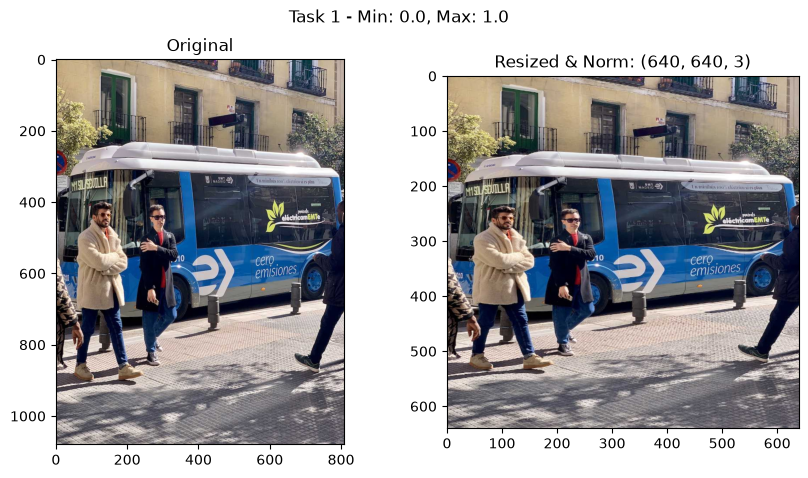

In [2]:
# ==========================================
# TASK 1: Preprocessing Pipeline
# ==========================================
img = cv2.imread('traffic.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(img_rgb, (640, 640))
img_norm = img_resized / 255.0

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(img_rgb); ax[0].set_title("Original")
ax[1].imshow(img_norm); ax[1].set_title(f"Resized & Norm: {img_norm.shape}")
plt.suptitle(f"Task 1 - Min: {img_norm.min():.1f}, Max: {img_norm.max():.1f}")
plt.show()


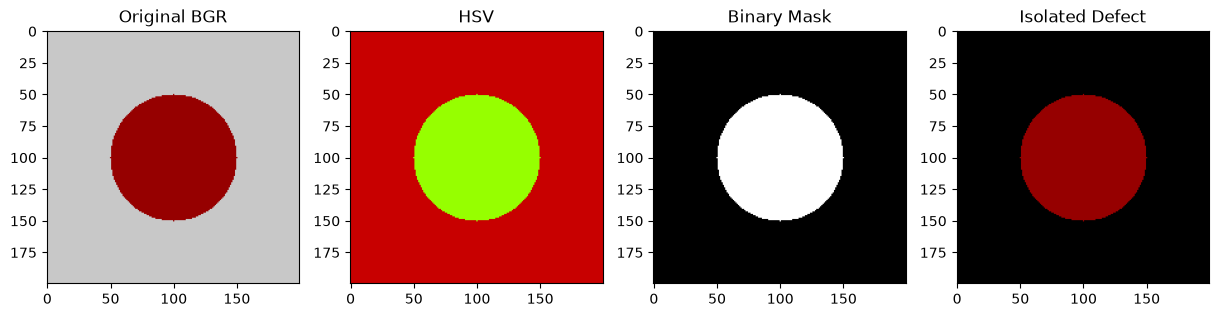

In [3]:
# ==========================================
# TASK 2: Industrial Defect Detection
# ==========================================
# Creating a synthetic "industrial" image for demonstration
img_ind = np.ones((200, 200, 3), dtype=np.uint8) * 200
cv2.circle(img_ind, (100, 100), 50, (0, 0, 150), -1) # Dark red "defect"

hsv = cv2.cvtColor(img_ind, cv2.COLOR_BGR2HSV)
lab = cv2.cvtColor(img_ind, cv2.COLOR_BGR2LAB)

lower_red = np.array([0, 120, 70])
upper_red = np.array([10, 255, 255])
mask = cv2.inRange(hsv, lower_red, upper_red)
result = cv2.bitwise_and(img_ind, img_ind, mask=mask)

fig, ax = plt.subplots(1, 4, figsize=(15, 4))
titles = ["Original BGR", "HSV", "Binary Mask", "Isolated Defect"]
images = [img_ind, hsv, mask, result]
for i, a in enumerate(ax): a.imshow(cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB) if i!=2 else mask, cmap='gray'); a.set_title(titles[i])
plt.show()

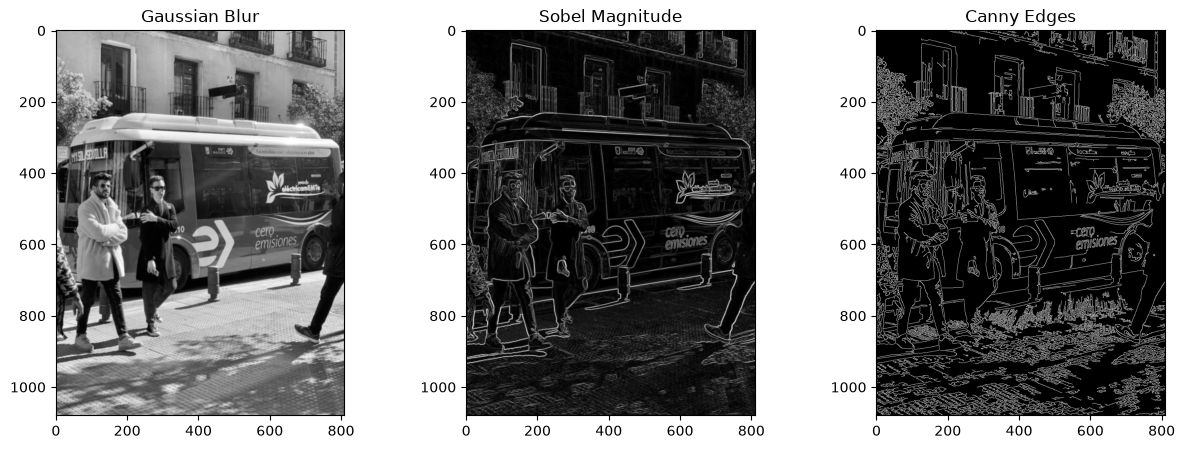

In [4]:
# ==========================================
# TASK 3: Medical Edge Detection
# ==========================================
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) # Using traffic as proxy
blur_gauss = cv2.GaussianBlur(gray, (5, 5), 0)
blur_med = cv2.medianBlur(gray, 5)

sobel_x = cv2.Sobel(blur_gauss, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(blur_gauss, cv2.CV_64F, 0, 1, ksize=3)
sobel_mag = cv2.magnitude(sobel_x, sobel_y)

canny = cv2.Canny(blur_gauss, 50, 150)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(blur_gauss, cmap='gray'); ax[0].set_title("Gaussian Blur")
ax[1].imshow(sobel_mag, cmap='gray'); ax[1].set_title("Sobel Magnitude")
ax[2].imshow(canny, cmap='gray'); ax[2].set_title("Canny Edges")
plt.show()

In [5]:
# ==========================================
# TASK 4: YOLO Benchmarking
# ==========================================
model_n = YOLO('yolov8n.pt')
model_m = YOLO('yolov8m.pt')

res_n = model_n('traffic.jpg', verbose=False)[0]
res_m = model_m('traffic.jpg', verbose=False)[0]

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(cv2.cvtColor(res_n.plot(), cv2.COLOR_BGR2RGB))
ax[0].set_title(f"YOLOv8 Nano - {res_n.speed['inference']:.1f}ms - {len(res_n.boxes)} objects")

ax[1].imshow(cv2.cvtColor(res_m.plot(), cv2.COLOR_BGR2RGB))
ax[1].set_title(f"YOLOv8 Medium - {res_m.speed['inference']:.1f}ms - {len(res_m.boxes)} objects")
plt.show()

RuntimeError: operator torchvision::nms does not exist

In [ ]:
# ==========================================
# TASK 5: Retail Inventory (Class Filtering)
# ==========================================
target_class_id = 0 # Looking for 'person' (ID 0) in the Zidane image
results = model_n('retail.jpg', verbose=False)[0]

count = 0
img_retail = cv2.imread('retail.jpg')
for box in results.boxes:
    if int(box.cls[0]) == target_class_id and float(box.conf[0]) > 0.50:
        count += 1
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        cv2.rectangle(img_retail, (x1, y1), (x2, y2), (255, 0, 0), 3)

cv2.putText(img_retail, f"Target Item Count: {count}", (20, 50), cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0, 0, 255), 4)
plt.imshow(cv2.cvtColor(img_retail, cv2.COLOR_BGR2RGB)); plt.title("Task 5: Filtered Counting"); plt.show()


In [ ]:
# ==========================================
# TASK 6: ROI Security Intrusion
# ==========================================
img_roi = cv2.imread('traffic.jpg')
polygon = np.array([[100, 500], [700, 500], [600, 300], [200, 300]], np.int32)

intrusion = False
for box in res_n.boxes:
    if int(box.cls[0]) == 0: # If person
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        cx, cy = int((x1+x2)/2), int((y1+y2)/2)
        cv2.circle(img_roi, (cx, cy), 5, (255, 0, 0), -1)
        
        # Check if centroid is inside polygon
        if cv2.pointPolygonTest(polygon, (cx, cy), False) >= 0:
            intrusion = True

color = (0, 0, 255) if intrusion else (0, 255, 0)
text = "INTRUSION DETECTED" if intrusion else "SECURE"
cv2.polylines(img_roi, [polygon], True, color, 4)
cv2.putText(img_roi, text, (20, 50), cv2.FONT_HERSHEY_SIMPLEX, 1.5, color, 4)

plt.imshow(cv2.cvtColor(img_roi, cv2.COLOR_BGR2RGB)); plt.title("Task 6: ROI Alert"); plt.show()